In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV files
df_a = pd.read_csv("code/data/camera_event_A.csv")
df_b = pd.read_csv("code/data/camera_event_B.csv")
df_c = pd.read_csv("code/data/camera_event_C.csv")
df_a["timestamp"] = pd.to_datetime(df_a["timestamp"])
df_b["timestamp"] = pd.to_datetime(df_b["timestamp"])
df_c["timestamp"] = pd.to_datetime(df_c["timestamp"])

df_a.head()

,event_id,batch_id,car_plate,camera_id,timestamp,speed_reading
0,d40c586c-5be6-4743-a1e3-2269d9edaa72,1,KRN 7,1,2024-01-01 08:00:04,77.2
1,85c08e3c-a0b5-45d8-a70c-df8f9a6d5829,1,ICE 8,1,2024-01-01 08:00:05,103.7
2,f5834b79-771b-4931-8da2-a5ad7f4ccd02,1,QE 1820,1,2024-01-01 08:00:03,67.4
3,d0e547bb-c4a7-4750-b7b4-8076e9b47f4f,1,CJW 924,1,2024-01-01 08:00:01,148.3
4,f3162606-1b2e-407f-951d-61d14c0a7b09,1,CJP 278,1,2024-01-01 08:00:02,125.2


In [2]:
a_timestamp = df_a["timestamp"].cummax()
a_diff = (df_a["timestamp"] - a_timestamp).dt.total_seconds()
a_diff.min() # Minimum time difference to get the latest timestamp for watermarking

-5.0

In [3]:
b_timestamp = df_b["timestamp"].cummax()
b_diff = (df_b["timestamp"] - b_timestamp).dt.total_seconds()
b_diff.min() # Minimum time difference to get the latest timestamp for watermarking

-646.125702

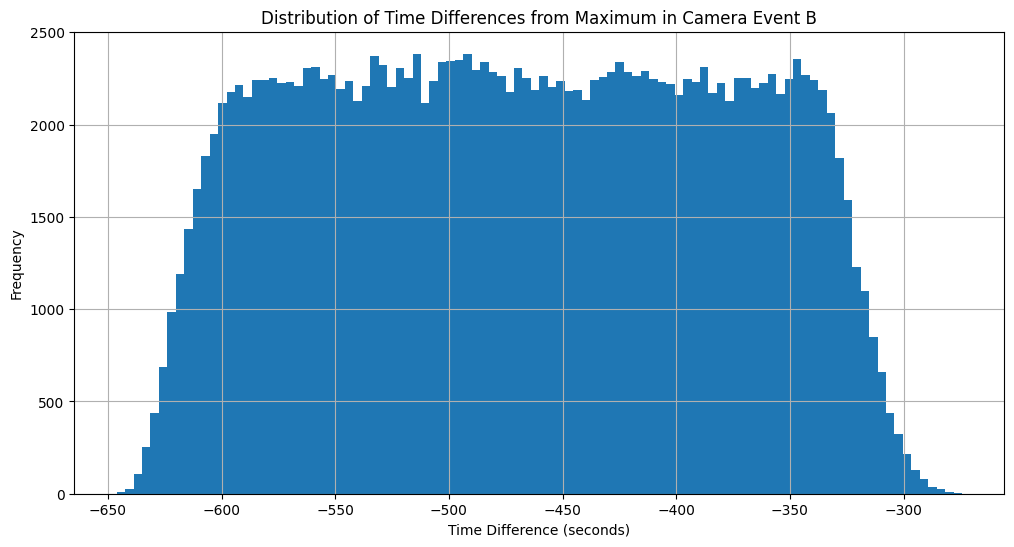

In [7]:
b_diff = b_diff[b_diff < -100]
plt.figure(figsize=(12, 6))
b_diff.hist(bins=100)
plt.title("Distribution of Time Differences from Maximum in Camera Event B")
plt.xlabel("Time Difference (seconds)")
plt.ylabel("Frequency")
plt.show()

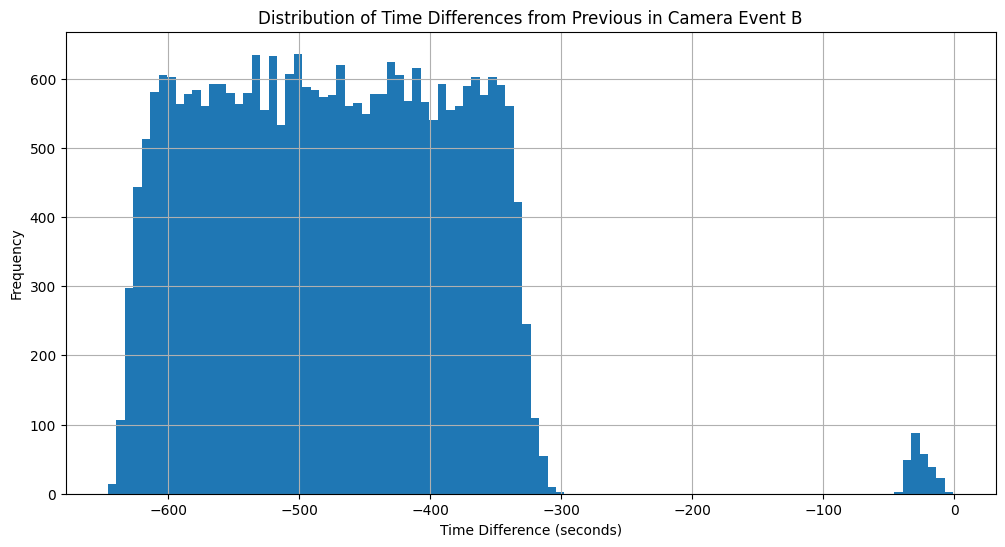

In [5]:
b_prev_diff = df_b["timestamp"].diff().dt.total_seconds()
plt.figure(figsize=(12, 6))
b_prev_diff[b_prev_diff < 0].hist(bins=100)
plt.title("Distribution of Time Differences from Previous in Camera Event B")
plt.xlabel("Time Difference (seconds)")
plt.ylabel("Frequency")
plt.show()


In [4]:
c_timestamp = df_c["timestamp"].cummax()
c_diff = (df_c["timestamp"] - c_timestamp).dt.total_seconds()
c_diff.min() # Minimum time difference to get the latest timestamp for watermarking

-1833.866859

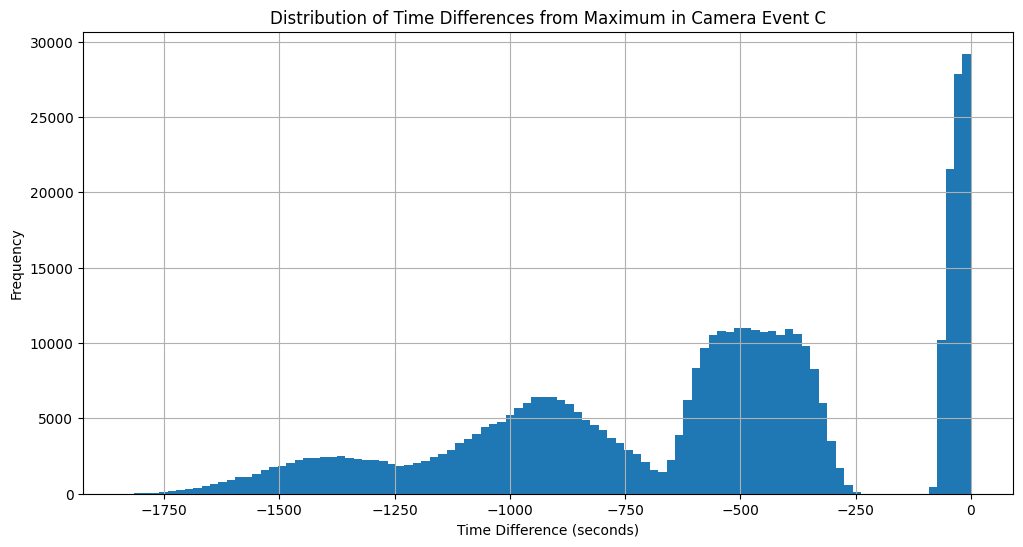

In [7]:
c_timestamp = df_c["timestamp"].cummax()
c_diff = (df_c["timestamp"] - c_timestamp).dt.total_seconds()
c_diff = c_diff[c_diff < 0]

plt.figure(figsize=(12, 6))
c_diff.hist(bins=100)
plt.title("Distribution of Time Differences from Maximum in Camera Event C")
plt.xlabel("Time Difference (seconds)")
plt.ylabel("Frequency")
plt.show()

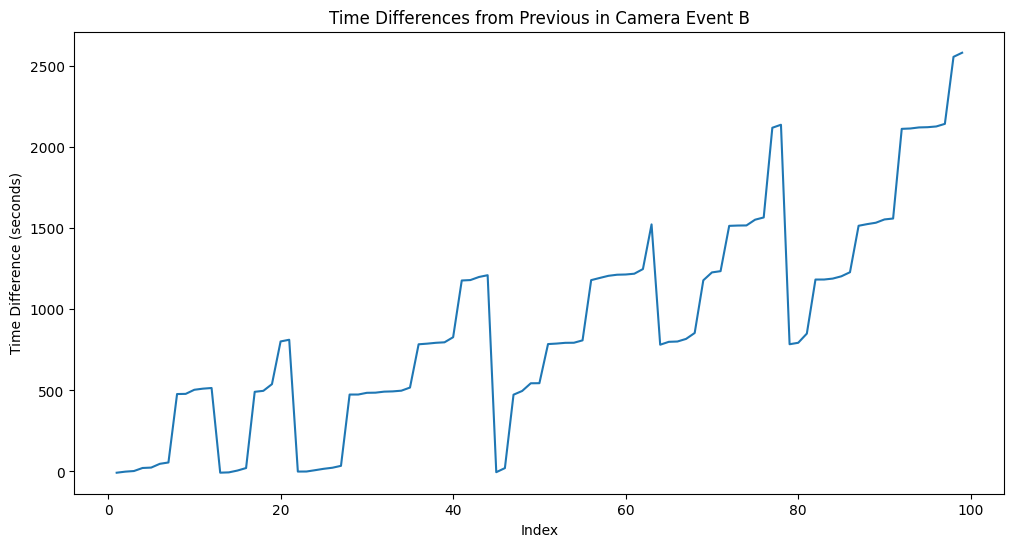

In [14]:

plt.figure(figsize=(12, 6))
b_line = df_c["timestamp"][:100].diff().dt.total_seconds().cumsum()
b_line.plot()
plt.title("Time Differences from Previous in Camera Event B")
plt.xlabel("Index")
plt.ylabel("Time Difference (seconds)")
plt.show()


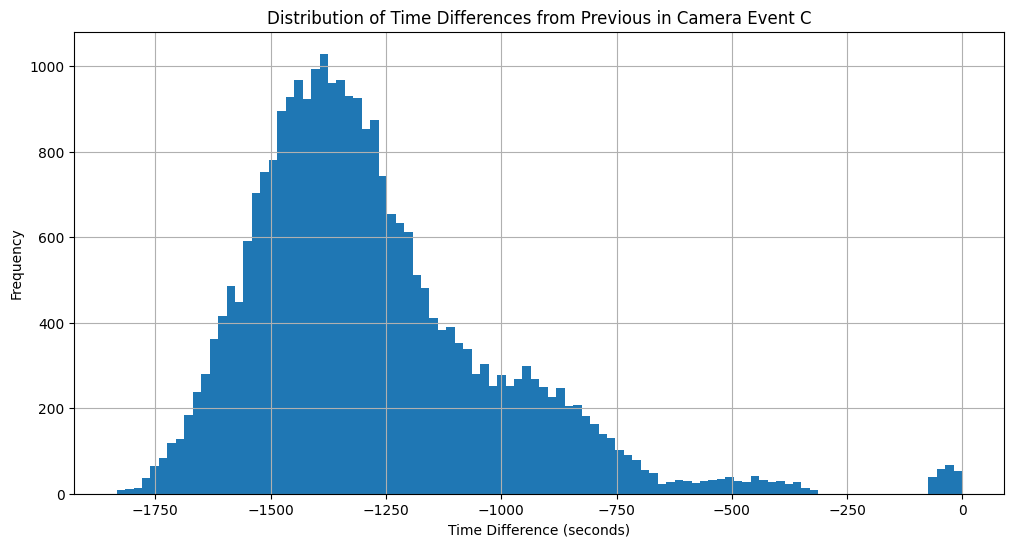

In [9]:
c_prev_diff = df_c["timestamp"].diff().dt.total_seconds()
plt.figure(figsize=(12, 6))
c_prev_diff[c_prev_diff < 0].hist(bins=100)
plt.title("Distribution of Time Differences from Previous in Camera Event C")
plt.xlabel("Time Difference (seconds)")
plt.ylabel("Frequency")
plt.show()